# Proyek Klasifikasi Gambar: Food-101
- **Nama:** Ndaniel Mahulae
- **Email:** danielmahulae88@gmail.com
- **ID Dicoding:** mahulaedan

**Sumber Dataset** : [Dataset Food-101](https://data.vision.ee.ethz.ch/cvl/datasets_extra/food-101/)

## Import Semua Packages/Library yang Digunakan

In [1]:
!pip install tensorflowjs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 3.3 MB/s eta 0:00:00
  Attempting uninstall: packaging
    Found existing installation: packaging 25.0
    Uninstalling packaging-25.0:
      Successfully uninstalled packaging-25.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.31.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.21.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
ray 2.53.0 requires packaging>=24.2, but you have packaging 23.2 which is incompatible.
build 1.4.0 requires packaging>=24.0, but you have packaging 23.2 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==

In [2]:
# Mengimpor libraries umum yang sering digunakan
import os, shutil
import zipfile
import random
from random import sample
import shutil
from shutil import copyfile
import pathlib
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm as tq
import tensorflowjs as tfjs

# Mengimpor libraries untuk visualisasi
%matplotlib inline
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.image import imread

# Mengimpor libraries untuk pemrosesan data gambar
import cv2
from PIL import Image
import skimage
from skimage import io
from skimage.transform import resize
from skimage.transform import rotate, AffineTransform, warp
from skimage import img_as_ubyte
from skimage.exposure import adjust_gamma
from skimage.util import random_noise

# Mengimpor libraries untuk pembuatan dan evaluasi model
import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import Model, layers
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.layers import InputLayer, Conv2D, SeparableConv2D, MaxPooling2D, MaxPool2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, Callback, EarlyStopping, ReduceLROnPlateau

# Mengimpor model
from tensorflow.keras import models
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.densenet import DenseNet201, preprocess_input
from tensorflow.keras.regularizers import l2
import math
# Mengabaikan peringatan
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

2026-09-03 13:10:59.817227: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1788441060.074950      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1788441060.146813      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1788441060.751758      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1788441060.751825      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1788441060.751828      57 computation_placer.cc:177] computation placer alr

In [3]:
# Mencetak versi TensorFlow yang sedang digunakan
print(tf.__version__)

2.19.0


## Data Preparation

### Data Loading

In [4]:
base_path = "/kaggle/input/datasets/danielmahulae/gambar-makanan/food-101"
image_path = os.path.join(base_path, "images")
meta_path = os.path.join(base_path, "meta")

# membaca nama kelas
with open(os.path.join(meta_path, "classes.txt")) as f:
    classes = f.read().splitlines()

# ambil hanya 12 kelas yang dipilih
selected_classes = [
    'donuts',          	 # bulet, berlubang di tengah
    'bibimbap',          # Warna-warni melingkar, ada telur di tengah
    'edamame',           # Hijau pekat, bentuk polong
    'french_fries',      # Kuning, batang panjang
    'ramen',             # mi jepang
    'hot_dog',           # Memanjang, roti dan sosis
    'ice_cream',         # Bulat (scoop), warna pastel
    'miso_soup',         # Cairan gelap di mangkuk
    'mussels',           # Cangkang hitam keunguan
    'pizza',             # Segitiga/bulat dengan topping merah/kuning
    'sashimi',           # Irisan daging ikan mentah (biasanya oranye/merah)
    'spaghetti_bolognese'# Mi panjang dengan saus merah
]

data=[]

for cls in selected_classes:
    
    class_folder = os.path.join(image_path, cls)
    images = os.listdir(class_folder)
    
    for img in images:
        data.append({
            "image_path": os.path.join(class_folder, img),
            "label": cls
        })
 
df = pd.DataFrame(data)

print(df.shape)

(12000, 2)


Saya mengambil 12 label agar mengurangi kompleksitas dan memilih kelas yang lebih gampang dibaca

In [5]:
def print_images_resolution(directory, classes_subset):
    total_images = 0
 
    for subdir in classes_subset:
        unique_sizes = set()
        subdir_path = os.path.join(directory, subdir)
        image_files = os.listdir(subdir_path)
        num_images = len(image_files)
        print(f"{subdir}: {num_images}")
        total_images += num_images
 
        for img_file in image_files[:5]:
            img_path = os.path.join(subdir_path, img_file)
            with Image.open(img_path) as img:
                unique_sizes.add(img.size)

        for size in unique_sizes:
            print(f"- {size}")
        print("---------------")
 
    print(f"\nTotal: {total_images}")

In [6]:
# Cek resolusi

print_images_resolution(image_path,selected_classes)

donuts: 1000
- (512, 512)
---------------
bibimbap: 1000
- (512, 341)
- (512, 512)
---------------
edamame: 1000
- (512, 512)
- (512, 384)
---------------
french_fries: 1000
- (512, 512)
- (306, 512)
---------------
ramen: 1000
- (512, 512)
- (512, 384)
---------------
hot_dog: 1000
- (512, 512)
- (382, 512)
- (512, 384)
- (512, 306)
---------------
ice_cream: 1000
- (384, 512)
- (512, 512)
- (512, 384)
---------------
miso_soup: 1000
- (512, 512)
- (382, 512)
- (512, 384)
- (510, 512)
---------------
mussels: 1000
- (512, 512)
- (382, 512)
- (512, 384)
---------------
pizza: 1000
- (512, 382)
- (512, 512)
- (512, 384)
- (512, 307)
---------------
sashimi: 1000
- (512, 512)
- (512, 384)
---------------
spaghetti_bolognese: 1000
- (512, 512)
- (512, 384)
---------------

Total: 12000


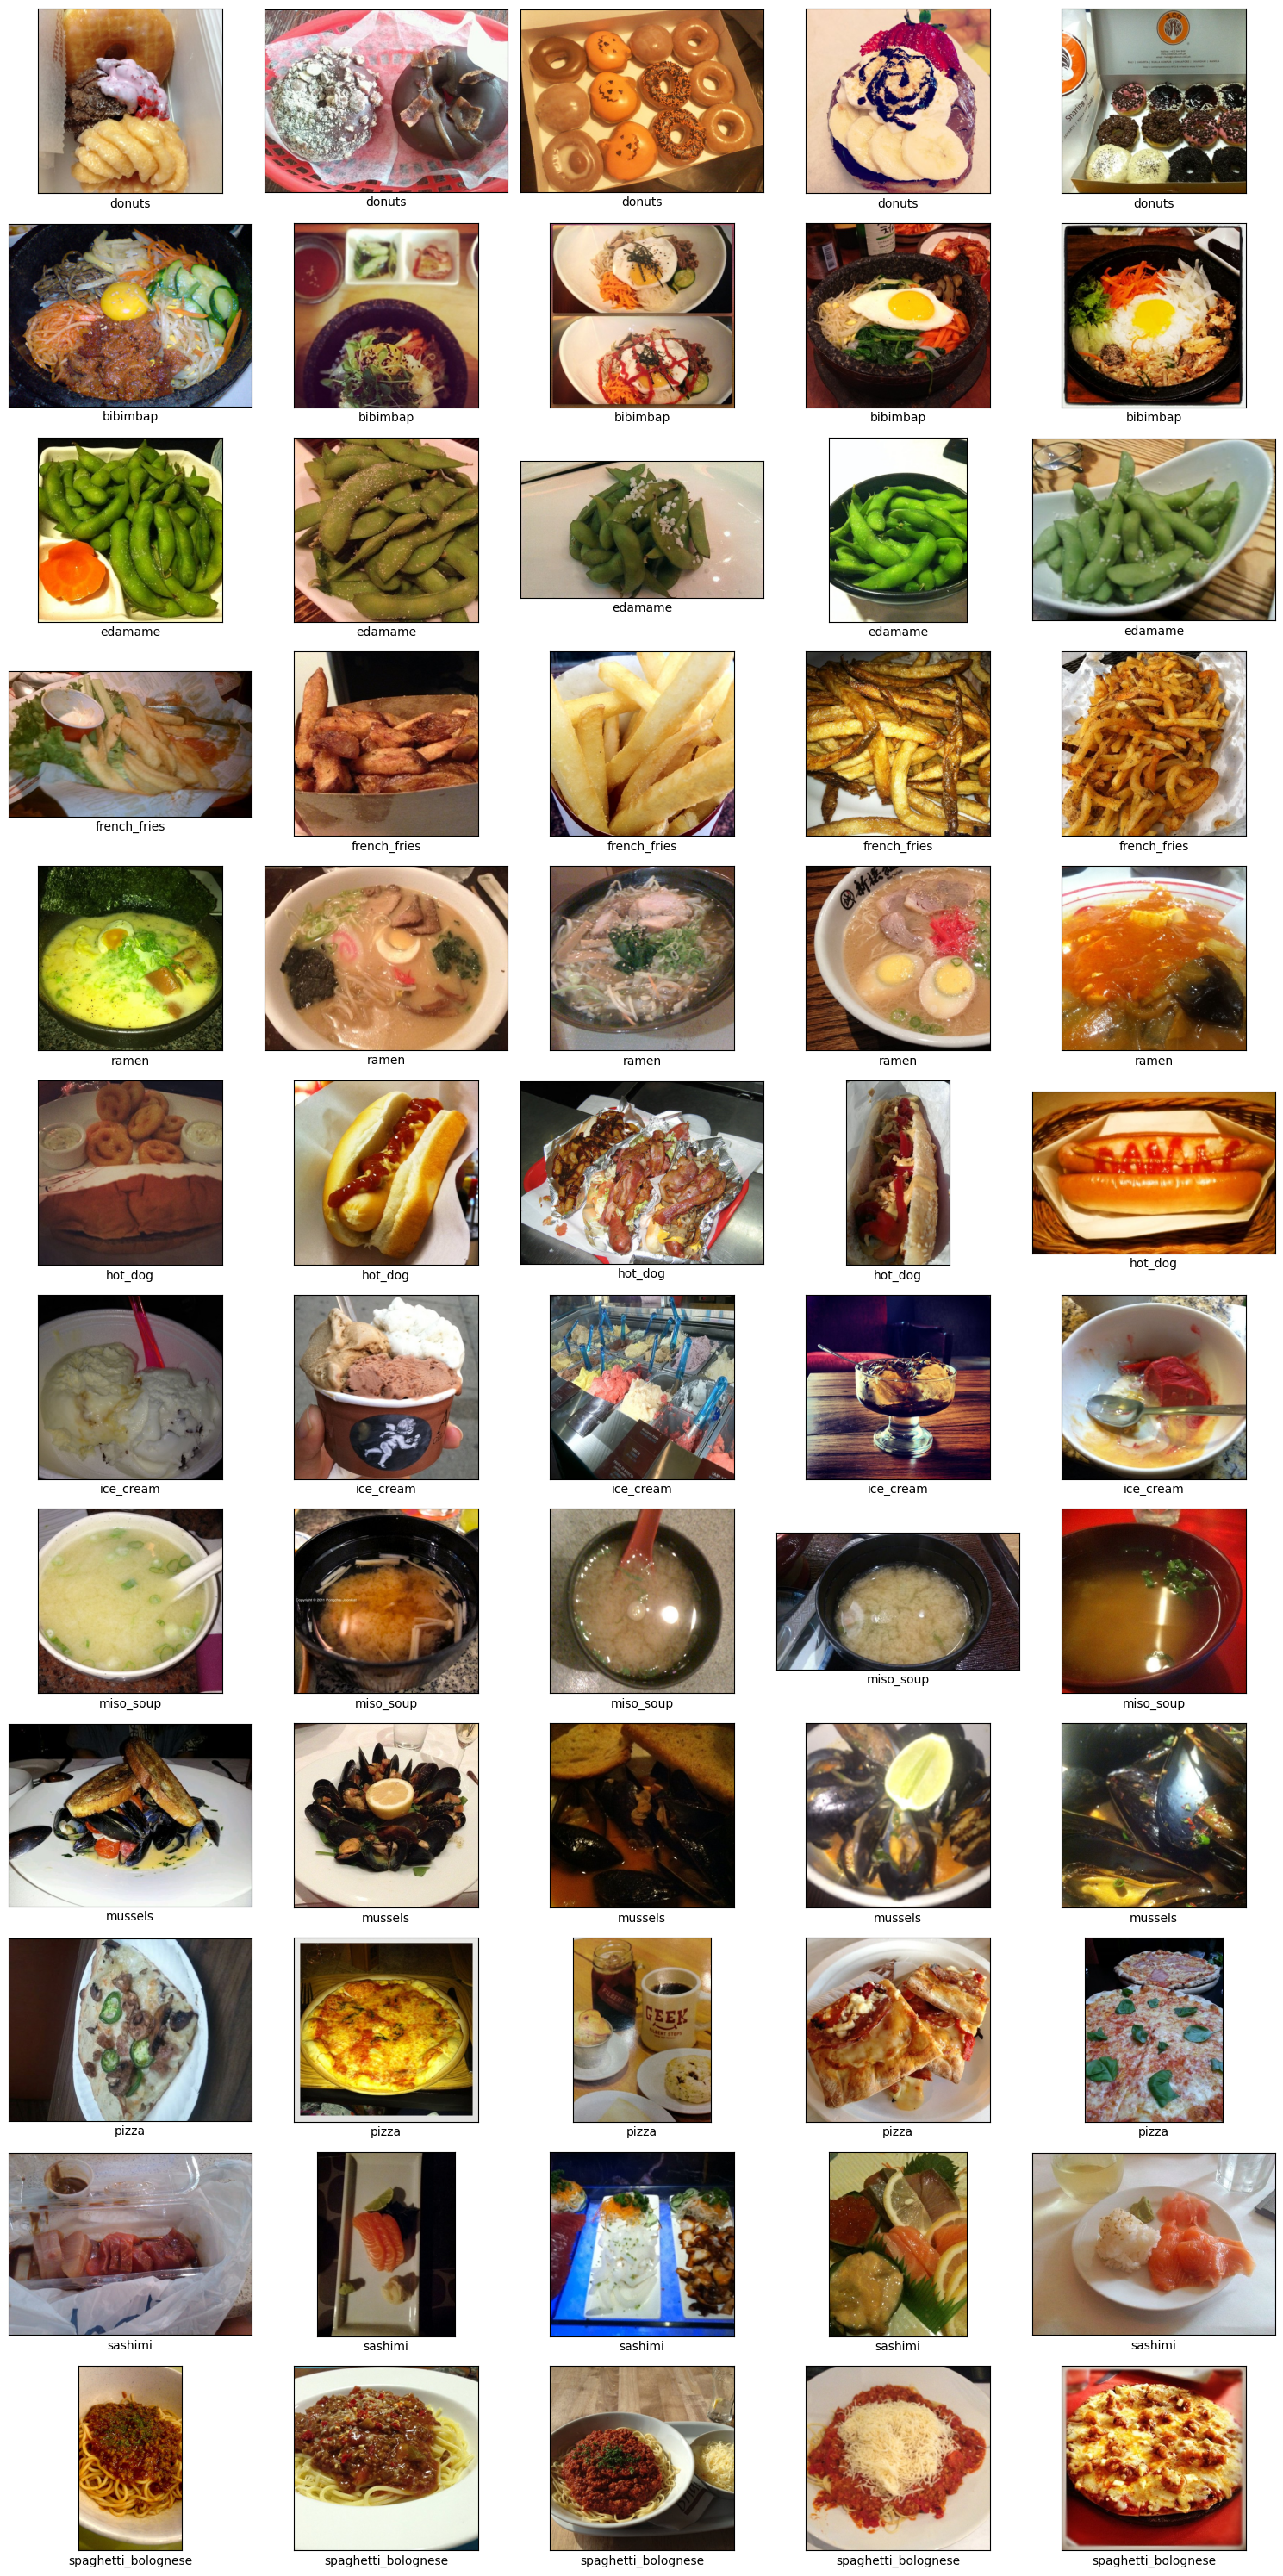

In [7]:
fig, axs = plt.subplots(len(selected_classes), 5, figsize=(15, 30))

for i, class_name in enumerate(selected_classes):
    class_folder = os.path.join(image_path, class_name)
    
    all_imgs = os.listdir(class_folder)
    images = np.random.choice(all_imgs, 5, replace=False)

    for j, image_name in enumerate(images):
        img_path = os.path.join(class_folder, image_name)
        img = Image.open(img_path)

        axs[i, j].imshow(img)
        axs[i, j].set(xlabel=class_name, xticks=[], yticks=[])

plt.tight_layout()
plt.show()

### Distribusi Resolusi Gambar

In [8]:
# Menghitung lebar dan tinggi seluruh gambar pada kelas yang dipilih
widths = []
heights = []

for cls in selected_classes:
    class_folder = os.path.join(image_path, cls)
    for img_file in os.listdir(class_folder):
        img_path = os.path.join(class_folder, img_file)
        with Image.open(img_path) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)
            
print(f"Lebar  - min: {min(widths)}, max: {max(widths)}, rata-rata: {np.mean(widths):.1f}")
print(f"Tinggi - min: {min(heights)}, max: {max(heights)}, rata-rata: {np.mean(heights):.1f}")

Lebar  - min: 193, max: 512, rata-rata: 493.8
Tinggi - min: 239, max: 512, rata-rata: 475.5


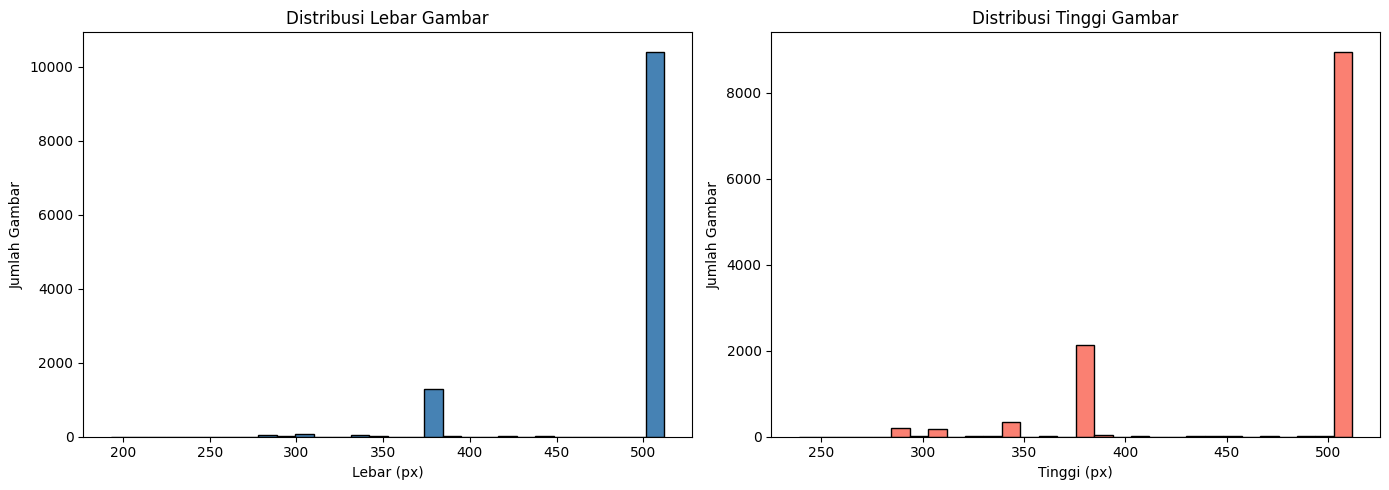

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].hist(widths, bins=30, color="steelblue", edgecolor="black")
axs[0].set_title("Distribusi Lebar Gambar")
axs[0].set_xlabel("Lebar (px)")
axs[0].set_ylabel("Jumlah Gambar")

axs[1].hist(heights, bins=30, color="salmon", edgecolor="black")
axs[1].set_title("Distribusi Tinggi Gambar")
axs[1].set_xlabel("Tinggi (px)")
axs[1].set_ylabel("Jumlah Gambar")

plt.tight_layout()
plt.show()

Plot di atas menunjukkan bahwa resolusi gambar pada dataset tidak sepenuhnya berukuran sama. sehingga dilakukan proses resizing ke ukuran seragam (300x300) sebelum training.

### Data Preprocessing

#### Split Dataset

Dataset Food-101 terdiri dari 101 kelas makanan dengan 1.000 gambar pada setiap kelas. Sehingga, setiap kelas memiliki distribusi yang sama. Oleh karena itu, saya membagi tiap kelas yang telah dipilih(12 kelas) menjadi data latih, validasi, dan pengujian dengan perbandingan 600 : 150 : 250 untuk setiap kelas, sehingga dataset ini bersifat balanced dan tidak memerlukan penanganan khusus untuk masalah ketidakseimbangan kelas.

In [10]:
train_list = open(os.path.join(meta_path,"train.txt")).read().splitlines() 
test_list = open(os.path.join(meta_path,"test.txt")).read().splitlines()

# TRAIN set awal 
train_data = []

for item in train_list:
    
    label = item.split("/")[0]
    
    # hanya ambil kelas yang dipilih (750 per kelas)
    if label in selected_classes:
        train_data.append({
            "path": os.path.join(image_path, item + ".jpg"),
            "label": label
        })

train_df = pd.DataFrame(train_data)

# TEST set 
test_data = []

for item in test_list:
    
    label = item.split("/")[0]

    # hanya ambil kelas yang dipillih (250 per kelas)
    if label in selected_classes:
        test_data.append({
            "path": os.path.join(image_path, item + ".jpg"),
            "label": label
        })

test_df = pd.DataFrame(test_data)

# mengambil 600 train per kelas
train_sample = train_df.groupby("label").sample(n=600, random_state=42)

# sisa train (150 per kelas) akan menjadi data validation
remaining = train_df.drop(train_sample.index)

# menyimpan data ke dalam variabel val_sample
val_sample = remaining.groupby("label").sample(n=150, random_state=42)

# cek jumlah
print("Train:", train_sample.shape)
print("Validation:", val_sample.shape)
print("Test:", test_df.shape)

Train: (7200, 2)
Validation: (1800, 2)
Test: (3000, 2)


#### Data Augmentation

In [11]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomContrast(0.05),
])

I0000 00:00:1788441183.259787      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788441183.266144      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [12]:
def random_erasing(image, label, prob=0.3, area_ratio=(0.02, 0.15)):
    """Menutup sebagian kecil area gambar dengan piksel acak (Cutout / Random Erasing)."""
    if tf.random.uniform([]) < prob:
        h = tf.shape(image)[0]
        w = tf.shape(image)[1]

        ratio = tf.random.uniform([], area_ratio[0], area_ratio[1]) ** 0.5
        erase_h = tf.cast(tf.cast(h, tf.float32) * ratio, tf.int32)
        erase_w = tf.cast(tf.cast(w, tf.float32) * ratio, tf.int32)

        y = tf.random.uniform([], 0, h - erase_h, dtype=tf.int32)
        x = tf.random.uniform([], 0, w - erase_w, dtype=tf.int32)

        mask = tf.pad(
            tf.zeros((erase_h, erase_w, 3)),
            [[y, h - y - erase_h], [x, w - x - erase_w], [0, 0]],
            constant_values=1
        )
        noise = tf.random.uniform(tf.shape(image), 0, 255)
        image = image * mask + noise * (1 - mask)

    return image, label

In [13]:
def mixup(images, labels, alpha=0.2):
    """Mencampur dua gambar dalam satu batch berdasarkan bobot lam (MixUp)."""
    batch_size = tf.shape(images)[0]
    indices = tf.random.shuffle(tf.range(batch_size))

    shuffled_images = tf.gather(images, indices)
    shuffled_labels = tf.gather(labels, indices)

    lam = np.random.beta(alpha, alpha)

    mixed_images = lam * images + (1 - lam) * shuffled_images
    mixed_labels = lam * labels + (1 - lam) * shuffled_labels

    return mixed_images, mixed_labels


def cutmix(images, labels, alpha=0.2):
    """Menempelkan potongan area dari satu gambar ke gambar lain dalam batch (CutMix)."""
    batch_size = tf.shape(images)[0]
    indices = tf.random.shuffle(tf.range(batch_size))

    shuffled_images = tf.gather(images, indices)
    shuffled_labels = tf.gather(labels, indices)

    lam = np.random.beta(alpha, alpha)

    h = tf.shape(images)[1]
    w = tf.shape(images)[2]

    cut_h = tf.cast(tf.cast(h, tf.float32) * tf.sqrt(1 - lam), tf.int32)
    cut_w = tf.cast(tf.cast(w, tf.float32) * tf.sqrt(1 - lam), tf.int32)

    cy = tf.random.uniform([], 0, h, dtype=tf.int32)
    cx = tf.random.uniform([], 0, w, dtype=tf.int32)

    y1 = tf.clip_by_value(cy - cut_h // 2, 0, h)
    y2 = tf.clip_by_value(cy + cut_h // 2, 0, h)
    x1 = tf.clip_by_value(cx - cut_w // 2, 0, w)
    x2 = tf.clip_by_value(cx + cut_w // 2, 0, w)

    mask = tf.pad(
        tf.ones((y2 - y1, x2 - x1, 1)),
        [[y1, h - y2], [x1, w - x2], [0, 0]]
    )
    mask = tf.tile(mask, [1, 1, 3])
    mask = tf.expand_dims(mask, 0)
    mask = tf.tile(mask, [batch_size, 1, 1, 1])

    mixed_images = images * (1 - mask) + shuffled_images * mask

    area_ratio = tf.cast((y2 - y1) * (x2 - x1), tf.float32) / tf.cast(h * w, tf.float32)
    lam_adjusted = 1 - area_ratio
    mixed_labels = lam_adjusted * labels + (1 - lam_adjusted) * shuffled_labels

    return mixed_images, mixed_labels

In [14]:
train_dataset_adv = tf.data.Dataset.from_generator(
    lambda: train_generator,
    output_signature=(
        tf.TensorSpec(shape=(None, 300, 300, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(None, len(selected_classes)), dtype=tf.float32)
    )
)

# Random Erasing diterapkan per-gambar 
# unbatch -> map -> batch kembali
train_dataset_adv = (
    train_dataset_adv
    .unbatch()
    .map(random_erasing, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(32)
)

# CutMix diterapkan per-batch 
train_dataset_adv = train_dataset_adv.map(
    lambda x, y: cutmix(x, y, alpha=0.2),
    num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

In [15]:
train_datagen = ImageDataGenerator() 
val_datagen = ImageDataGenerator()
test_datagen = ImageDataGenerator()

In [16]:
# TRAIN generator
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_sample,
    x_col="path",
    y_col="label",
    target_size=(300, 300),
    batch_size=32,
    class_mode="categorical",
    shuffle=True
)

# VALIDATION generator
val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_sample,
    x_col="path",
    y_col="label",
    target_size=(300, 300),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

# TEST generator
test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="path",
    y_col="label",
    target_size=(300, 300),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 7200 validated image filenames belonging to 12 classes.
Found 1800 validated image filenames belonging to 12 classes.
Found 3000 validated image filenames belonging to 12 classes.


## Modelling

In [17]:
base_model = DenseNet201(
    weights="imagenet",
    include_top=False,
    input_shape=(300, 300, 3)
)

base_model.trainable = False

model = models.Sequential([
    layers.Input(shape=(300, 300, 3)),
    data_augmentation,
    layers.Lambda(tf.keras.applications.densenet.preprocess_input),
    base_model,
    
    # Conv 

    layers.Conv2D(128, (3,3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),
    
    # feature compression
    layers.GlobalAveragePooling2D(),
    
    # classifier
    layers.BatchNormalization(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(12, activation="softmax")
])


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=["accuracy"]
)

print(model.summary())

74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet201 (Functional)        │ (None, 9, 9, 1920)     │    18,321,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 9, 9, 128)      │     2,211,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 9, 9, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         3,084 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,571,084 (78.47 MB)

 Trainable params: 2,248,588 (8.58 MB)

 Non-trainable params: 18,322,496 (69.89 MB)

None


### Callback

In [18]:
callbacks = [

    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3
    ),

    ModelCheckpoint(
        "best_food101_model.keras",
        monitor="val_accuracy",
        save_best_only=True
    )
]

### Training

In [19]:
history = model.fit(
    train_generator,
    epochs=25,
    validation_data=val_generator,
    callbacks=callbacks
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25


I0000 00:00:1788441228.784298     142 cuda_dnn.cc:529] Loaded cuDNN version 91002


225/225 ━━━━━━━━━━━━━━━━━━━━ 165s 575ms/step - accuracy: 0.8237 - loss: 0.8417 - val_accuracy: 0.9278 - val_loss: 0.5526 - learning_rate: 0.0010
Epoch 2/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 118s 524ms/step - accuracy: 0.9380 - loss: 0.5323 - val_accuracy: 0.9217 - val_loss: 0.5489 - learning_rate: 0.0010
Epoch 3/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 120s 534ms/step - accuracy: 0.9548 - loss: 0.4757 - val_accuracy: 0.9444 - val_loss: 0.5071 - learning_rate: 0.0010
Epoch 4/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 117s 521ms/step - accuracy: 0.9686 - loss: 0.4429 - val_accuracy: 0.9317 - val_loss: 0.5304 - learning_rate: 0.0010
Epoch 5/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 118s 522ms/step - accuracy: 0.9792 - loss: 0.4127 - val_accuracy: 0.9328 - val_loss: 0.5161 - learning_rate: 0.0010
Epoch 6/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 117s 521ms/step - accuracy: 0.9788 - loss: 0.4147 - val_accuracy: 0.9378 - val_loss: 0.5082 - learning_rate: 0.0010
Epoch 7/25
225/225 ━━━━━━━━━━━━━━━━━━━━ 118s 524ms/step - accuracy: 0.9869 

Fine tuning dengan unfreeze 30 layer 

In [20]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

In [21]:
history_ft = model.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator,
    callbacks=callbacks
)

Epoch 1/5
225/225 ━━━━━━━━━━━━━━━━━━━━ 165s 598ms/step - accuracy: 0.9972 - loss: 0.6100 - val_accuracy: 0.9367 - val_loss: 0.7188 - learning_rate: 1.0000e-05
Epoch 2/5
225/225 ━━━━━━━━━━━━━━━━━━━━ 124s 552ms/step - accuracy: 0.9959 - loss: 0.6031 - val_accuracy: 0.9389 - val_loss: 0.7166 - learning_rate: 1.0000e-05
Epoch 3/5
225/225 ━━━━━━━━━━━━━━━━━━━━ 124s 549ms/step - accuracy: 0.9980 - loss: 0.6008 - val_accuracy: 0.9400 - val_loss: 0.7122 - learning_rate: 1.0000e-05
Epoch 4/5
225/225 ━━━━━━━━━━━━━━━━━━━━ 124s 550ms/step - accuracy: 0.9979 - loss: 0.5947 - val_accuracy: 0.9406 - val_loss: 0.7098 - learning_rate: 1.0000e-05
Epoch 5/5
225/225 ━━━━━━━━━━━━━━━━━━━━ 124s 550ms/step - accuracy: 0.9981 - loss: 0.5932 - val_accuracy: 0.9411 - val_loss: 0.7075 - learning_rate: 1.0000e-05


## Evaluasi dan Visualisasi

### Plot Accuracy dan Loss

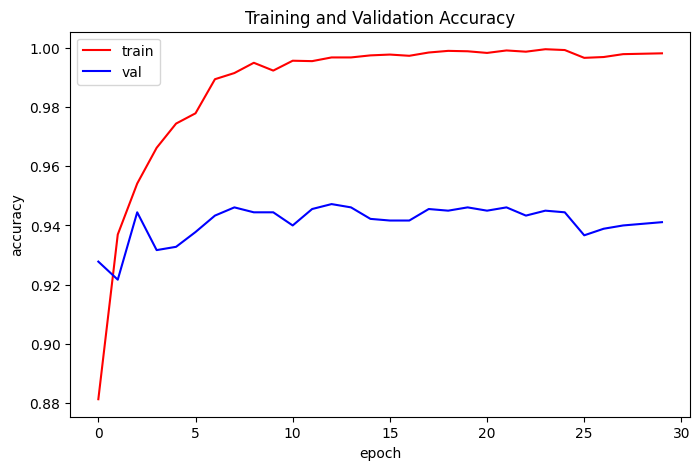

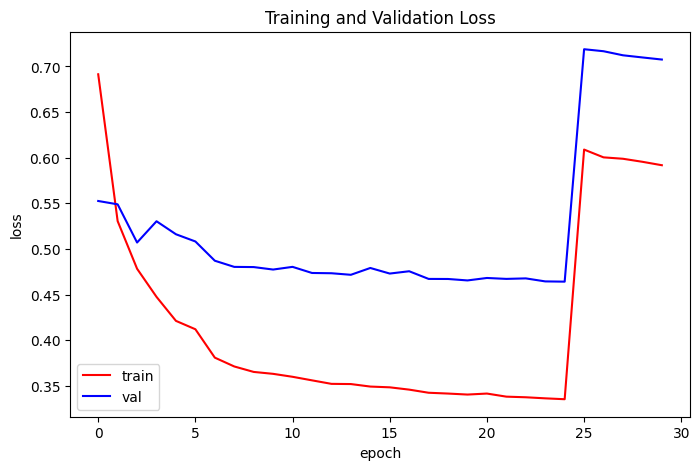

In [22]:
acc = history.history["accuracy"] + history_ft.history["accuracy"]
val_acc = history.history["val_accuracy"] + history_ft.history["val_accuracy"]
loss = history.history['loss'] + history_ft.history["loss"]
val_loss = history.history['val_loss'] + history_ft.history["val_loss"]

epochs = range(len(acc))

plt.figure(figsize=(8,5))
plt.plot(epochs, acc, 'r')
plt.plot(epochs, val_acc, 'b')
plt.title('Training and Validation Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','val'])
plt.show()

plt.figure(figsize=(8,5))
plt.plot(epochs, loss, 'r')
plt.plot(epochs, val_loss, 'b')
plt.title('Training and Validation Loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','val'])
plt.show()

### Evaluasi

In [23]:
test_generator.reset()

steps = math.ceil(test_generator.samples / test_generator.batch_size)

preds = model.predict(test_generator, steps=steps)

pred_labels = np.argmax(preds, axis=1)
true_labels = test_generator.classes

94/94 ━━━━━━━━━━━━━━━━━━━━ 57s 528ms/step


### Confusion Matrix

In [24]:
class_names = list(test_generator.class_indices.keys())

print(classification_report(
    true_labels,
    pred_labels,
    target_names=class_names
))

                     precision    recall  f1-score   support

           bibimbap       0.96      0.95      0.96       250
             donuts       0.96      0.95      0.96       250
            edamame       1.00      1.00      1.00       250
       french_fries       0.97      0.98      0.97       250
            hot_dog       0.98      0.95      0.96       250
          ice_cream       0.96      0.94      0.95       250
          miso_soup       0.97      0.97      0.97       250
            mussels       0.99      0.94      0.97       250
              pizza       0.96      0.99      0.98       250
              ramen       0.92      0.96      0.94       250
            sashimi       0.98      0.99      0.98       250
spaghetti_bolognese       0.96      0.97      0.96       250

           accuracy                           0.97      3000
          macro avg       0.97      0.97      0.97      3000
       weighted avg       0.97      0.97      0.97      3000



In [25]:
test_loss, test_acc = model.evaluate(test_generator)

print("Test Accuracy:", test_acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 38s 404ms/step - accuracy: 0.9620 - loss: 0.6571
Test Accuracy: 0.9666666388511658


## Konversi Model

### MEMBUAT DEPLOY MODEL

In [26]:
# Menyusun ulang layer
input_layer = tf.keras.Input(shape=(300, 300, 3), name="input_1")
x = layers.Lambda(tf.keras.applications.densenet.preprocess_input, name="preprocess_input")(input_layer)

base_model_layer = model.get_layer('densenet201')
x = base_model_layer(x)

# Mengambil sisa layer
x = model.get_layer('conv2d')(x)
x = model.get_layer('batch_normalization')(x)
x = model.get_layer('activation')(x)
x = model.get_layer('max_pooling2d')(x)
x = model.get_layer('global_average_pooling2d')(x)
x = model.get_layer('batch_normalization_1')(x)
x = model.get_layer('dense')(x)
x = model.get_layer('dropout')(x)
output_layer = model.get_layer('dense_1')(x)

deploy_model = tf.keras.Model(inputs=input_layer, outputs=output_layer)

### Menyimpan Model

In [27]:
model.save('food_model_v1.keras')

#### SavedModel

In [28]:
# Simpan sebagai SavedModel

export_path = 'saved_model/food_model_v1'
deploy_model.export(export_path)

INFO:tensorflow:Assets written to: saved_model/food_model_v1/assets


INFO:tensorflow:Assets written to: saved_model/food_model_v1/assets


Saved artifact at 'saved_model/food_model_v1'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 300, 300, 3), dtype=tf.float32, name='input_1')
Output Type:
  TensorSpec(shape=(None, 12), dtype=tf.float32, name=None)
Captures:
  137546593354384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137546593367056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137546593366864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137546593354960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137546593354192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137546593368976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137546593369168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137546593368400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137546593367440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137546593369360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137546327

#### TFLite

In [29]:
# Simpan sebagai TFLite

# Inisialisasi converter

converter = tf.lite.TFLiteConverter.from_keras_model(deploy_model)

tflite_model = converter.convert()

# Simpan file .tflite

with open('food_model.tflite', 'wb') as f:

    f.write(tflite_model)

INFO:tensorflow:Assets written to: /tmp/tmpu7o0sxz3/assets


INFO:tensorflow:Assets written to: /tmp/tmpu7o0sxz3/assets


Saved artifact at '/tmp/tmpu7o0sxz3'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 300, 300, 3), dtype=tf.float32, name='input_1')
Output Type:
  TensorSpec(shape=(None, 12), dtype=tf.float32, name=None)
Captures:
  137546593354384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137546593367056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137546593366864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137546593354960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137546593354192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137546593368976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137546593369168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137546593368400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137546593367440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137546593369360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137546327278800: T

W0000 00:00:1788445021.369459      57 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1788445021.369531      57 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1788445022.140025      57 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled


#### TFJS

In [30]:
# Simpan sebagai tfjs
tfjs.converters.save_keras_model(deploy_model, 'tfjs_model')

failed to lookup keras version from the file,
    this is likely a weight only file


## Inference

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


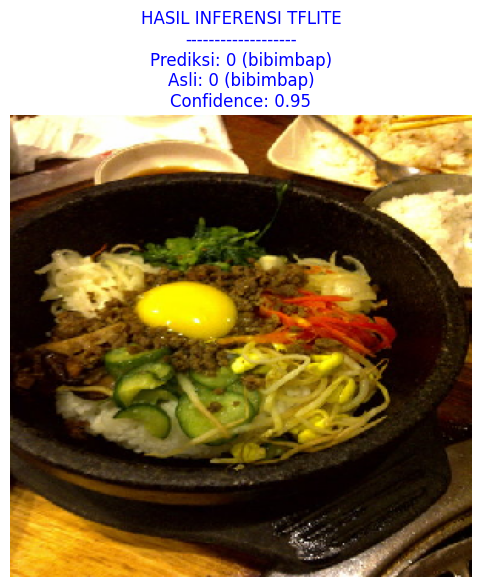

In [31]:
# Memuat Model TFLite yang BARU
interpreter = tf.lite.Interpreter(model_path="food_model.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Mengambil batch gambar 
test_images, test_labels = next(test_generator)
index_yg_dites = 2 

# Mengambil satu gambar dan diubah menjadi float32
image_to_test = test_images[index_yg_dites:index_yg_dites+1].astype(np.float32)

# Inferensi
interpreter.set_tensor(input_details[0]['index'], image_to_test)
interpreter.invoke()

# Hasil
output_data = interpreter.get_tensor(output_details[0]['index'])
predicted_class = np.argmax(output_data)
actual_class = np.argmax(test_labels[index_yg_dites])
labels = list(test_generator.class_indices.keys())

# Visualisasi 
plt.figure(figsize=(8, 6))
plt.imshow(test_images[index_yg_dites].astype('uint8')) # menggunakan uint8 agar bisa ditampilkan

plt.title(f"HASIL INFERENSI TFLITE\n-------------------\n"
          f"Prediksi: {predicted_class} ({labels[predicted_class]})\n"
          f"Asli: {actual_class} ({labels[actual_class]})\n"
          f"Confidence: {np.max(output_data):.2f}", 
          fontsize=12, color='blue' if predicted_class == actual_class else 'red')

plt.axis('off')
plt.show()

In [32]:
# mengambil daftar label dari class_indices
labels = sorted(test_generator.class_indices.items(), key=lambda x: x[1])
class_names = [row[0] for row in labels]

# Menyimpan ke file labels.txt
with open('labels.txt', 'w') as f:
    for name in class_names:
        f.write(name + '\n')

In [33]:
!pip freeze > requirements.txt

In [36]:
import shutil
from IPython.display import FileLink

# 1. Kompres folder 'saved_model' menjadi 'saved_model.zip'
shutil.make_archive('tfjs_model', 'zip', '/kaggle/working/tfjs_model')

# 2. Buat link unduhan untuk file zip tersebut
FileLink(r'tfjs_model.zip')


/kaggle/working/tfjs_model.zip